# 01_RQ1_Baseline_Models
Objective and methodology.

# ============================================
# RQ1: Baseline Performance 
# ============================================

In [2]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


# ============================================
# 2. Create Output Folder
# ============================================

In [3]:
os.makedirs('outputs', exist_ok=True)

# ============================================
# 3. Load Dataset
# ============================================

In [4]:
df = pd.read_csv('marketing_and_product_performance.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print(df.head())

Dataset Shape: (10000, 17)

Columns: ['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier', 'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold', 'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund', 'Common_Keywords']
  Campaign_ID   Product_ID    Budget  Clicks  Conversions  Revenue_Generated  \
0  CMP_RLSDVN  PROD_HBJFA3  41770.45    4946           73           15520.09   
1  CMP_JHHUE9  PROD_OE8YNJ  29900.93     570          510           30866.17   
2  CMP_6SBOWN  PROD_4V8A08  22367.45    3546          265           32585.62   
3  CMP_Q31QCU  PROD_A1Q6ZB  29957.54    2573          781           95740.12   
4  CMP_AY0UTJ  PROD_F57N66  36277.19     818           79           81990.43   

    ROI  Customer_ID Subscription_Tier  Subscription_Length Flash_Sale_ID  \
0  1.94  CUST_1K7G39           Premium                    4  FLASH_1VFK5K   
1  0.76  CUST_0DWS6F           Premium    

# ============================================
# 4. Feature Engineering 
# ============================================

In [5]:
# Check required columns
if 'Conversions' not in df.columns or 'Clicks' not in df.columns:
    raise ValueError("Dataset must contain 'Conversions' and 'Clicks' columns")

# Conversion Rate
df['Conversion_Rate'] = df['Conversions'] / df['Clicks']

# Handle division issues
df['Conversion_Rate'] = df['Conversion_Rate'].replace([np.inf, -np.inf], np.nan)
df['Conversion_Rate'] = df['Conversion_Rate'].fillna(0)

# Categorize target
def categorize_conversion(rate):
    if rate < 0.02:
        return 'Low'
    elif rate < 0.05:
        return 'Medium'
    else:
        return 'High'

df['Target'] = df['Conversion_Rate'].apply(categorize_conversion)

# Encode target
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

# ============================================
# 5. Data Preprocessing
# ============================================

In [6]:

# Drop helper column
df = df.drop(columns=['Conversion_Rate'], errors='ignore')

# Split features & target
X = df.drop(columns=['Target'])
y = df['Target']

# Handle categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (important for LR & KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# 6. Train Baseline Models
# ============================================

In [7]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])


# ============================================
# 7. Results Table
# ============================================

In [8]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

print("\nBaseline Results:\n")
print(results_df)

# Save CSV
results_df.to_csv('RQ1_outputs/RQ1_Baseline_Results.csv', index=False)


Baseline Results:

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.8725   0.761256  0.8725  0.813091
1        Decision Tree    0.9875   0.988100  0.9875  0.987690
2                  KNN    0.8725   0.761256  0.8725  0.813091


# ============================================
# 8. Visualization
# ============================================

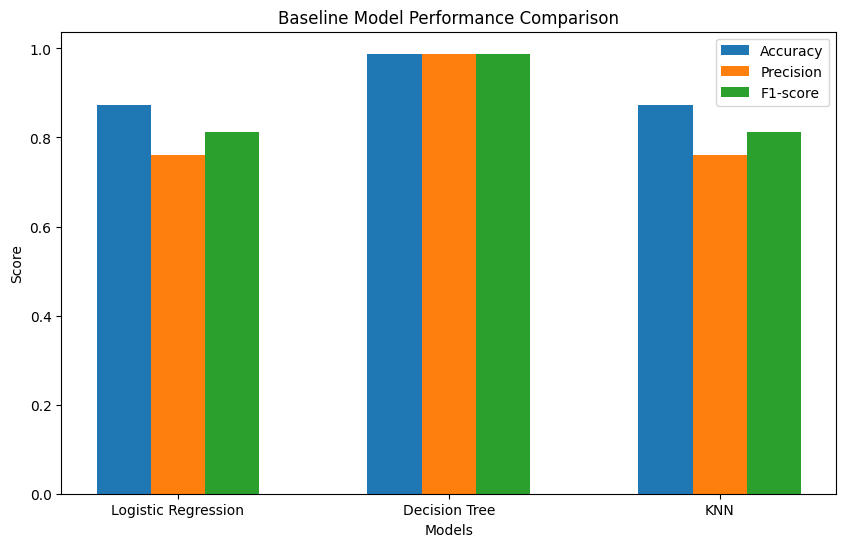

In [9]:
x = np.arange(len(results_df["Model"]))

plt.figure(figsize=(10,6))

plt.bar(x - 0.2, results_df["Accuracy"], width=0.2, label='Accuracy')
plt.bar(x, results_df["Precision"], width=0.2, label='Precision')
plt.bar(x + 0.2, results_df["F1-score"], width=0.2, label='F1-score')

plt.xticks(x, results_df["Model"])
plt.title("Baseline Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.legend()

# Save figure
plt.savefig('RQ1_outputs/RQ1_Baseline_Performance.pdf')

plt.show()


# ============================================
# 9. Best Model Summary
# ============================================

In [10]:
best_model = results_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("\nBest Baseline Model:")
print(best_model)


Best Baseline Model:
Model        Decision Tree
Accuracy            0.9875
Precision           0.9881
Recall              0.9875
F1-score           0.98769
Name: 1, dtype: object
